# 03 — Draft Value Model
**Finding Hidden Gems: 25 Years of WNBA Draft Value and Player Success**

Phase 2 looked at *players*. This notebook evaluates **picks** — for every draft slot,
1 through 64, what should a GM expect to get?

That expected-value curve is the foundation for everything downstream: Phase 4 (steal/bust
scoring) measures each player against it, and Phase 5 (team drafting ability) measures each
franchise against it.

### A key modeling choice, made explicit
When averaging outcomes "by pick," a player who never made a WNBA roster must count as a
**0**, not be dropped from the average. Dropping them would mean "expected value of pick #40"
secretly means "expected value of pick #40 *given the player made the league*" — which
defeats the purpose of a pick-value curve. Every stat below is computed over **all** picks
at a slot, zero-filled for players who never played.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLOR_MAIN = '#E56020'
COLOR_ALT  = '#1B3A5C'
COLOR_GREY = '#9AA5B1'

df = pd.read_csv('../data/wnba_draft_clean.csv')

# Zero-fill career outcomes for players who never played - this IS the value they delivered.
df['win_shares_ev']   = df['win_shares'].fillna(0)
df['games_ev']        = df['games'].fillna(0)
df['years_played_ev'] = df['years_played']  # already 0 for never-played in source data

STAR_THRESHOLD = 20.0  # win shares; ~90th percentile among players who played at all (see notebook 02)
df['is_star'] = df['win_shares_ev'] >= STAR_THRESHOLD

df[['overall_pick','player','win_shares_ev','never_played','is_star']].head()


,overall_pick,player,win_shares_ev,never_played,is_star
0,1,Tina Thompson,60.7,False,True
1,2,Pamela McGee,2.0,False,False
2,3,Jamila Wideman,-1.3,False,False
3,4,Eva Nemcova,10.4,False,False
4,5,Tammi Reiss,-0.1,False,False


## Raw per-pick statistics

Straight averages by exact overall pick number. Useful, but sample size collapses fast:
only 3-4 historical instances exist for picks beyond ~50 (the draft has been 36 picks since
2010, so anything past 36 only has data from the deeper 1997-2009 drafts).


In [2]:
pick_stats = df.groupby('overall_pick').agg(
    n=('player', 'count'),
    avg_win_shares=('win_shares_ev', 'mean'),
    avg_career_years=('years_played_ev', 'mean'),
    avg_games=('games_ev', 'mean'),
    bust_rate=('never_played', 'mean'),
    star_rate=('is_star', 'mean'),
).reset_index()

print(f"Sample size by pick: {(pick_stats.n >= 15).sum()} picks have 15+ historical instances, "
      f"{(pick_stats.n < 5).sum()} picks have fewer than 5.")
pick_stats.head(10).round(3)


Sample size by pick: 36 picks have 15+ historical instances, 21 picks have fewer than 5.


,overall_pick,n,avg_win_shares,avg_career_years,avg_games,bust_rate,star_rate
0,1,26,33.027,9.385,266.385,0.000,0.692
1,2,26,16.685,7.846,223.038,0.000,0.308
2,3,26,15.304,6.962,201.923,0.000,0.346
3,4,26,13.585,7.385,208.115,0.000,0.269
4,5,26,12.008,7.269,204.846,0.038,0.115
5,6,26,12.777,7.000,198.154,0.000,0.192
6,7,26,3.900,4.885,129.885,0.000,0.000
7,8,26,4.192,4.654,121.462,0.038,0.000
8,9,26,4.088,4.808,124.769,0.077,0.000
9,10,26,6.027,4.000,110.308,0.077,0.115


## Smoothed expected value curve

Raw per-pick means are noisy, especially late in the draft where sample sizes are tiny and
a single Taj McWilliams-Franklin (pick 32, 53.9 career win shares) swings the average wildly.
We fit a **LOWESS** (locally weighted smoothing) curve through the zero-filled win-share data
across all 1,064 individual picks — this is the **Expected Value (EV) curve**: what a GM
should statistically expect from any given slot, borrowing strength from neighboring picks.


In [3]:
smoothed = lowess(df['win_shares_ev'], df['overall_pick'], frac=0.25, return_sorted=True)
ev_curve = pd.DataFrame(smoothed, columns=['overall_pick', 'expected_win_shares'])
ev_curve['overall_pick'] = ev_curve['overall_pick'].round().astype(int)
ev_curve = ev_curve.groupby('overall_pick', as_index=False)['expected_win_shares'].mean()

# Expected value should never increase with a later pick (monotonicity is a sanity check,
# not an assumption we force) - flag if LOWESS produced any local increases.
diffs = ev_curve['expected_win_shares'].diff()
print(f"Picks where EV ticks up vs. the previous pick: {(diffs > 0).sum()} of {len(diffs)} "
      f"(minor LOWESS noise is expected and fine; a large count would signal a smoothing problem)")

pick_stats = pick_stats.merge(ev_curve, on='overall_pick', how='left')
pick_stats[['overall_pick','n','avg_win_shares','expected_win_shares','bust_rate','star_rate']].round(3).head(15)


Picks where EV ticks up vs. the previous pick: 4 of 64 (minor LOWESS noise is expected and fine; a large count would signal a smoothing problem)


,overall_pick,n,avg_win_shares,expected_win_shares,bust_rate,star_rate
0,1,26,33.027,22.217,0.000,0.692
1,2,26,16.685,19.832,0.000,0.308
2,3,26,15.304,17.452,0.000,0.346
3,4,26,13.585,15.077,0.000,0.269
4,5,26,12.008,12.701,0.038,0.115
5,6,26,12.777,10.301,0.000,0.192
6,7,26,3.900,8.051,0.000,0.000
7,8,26,4.192,6.040,0.038,0.000
8,9,26,4.088,4.307,0.077,0.000
9,10,26,6.027,2.881,0.077,0.115


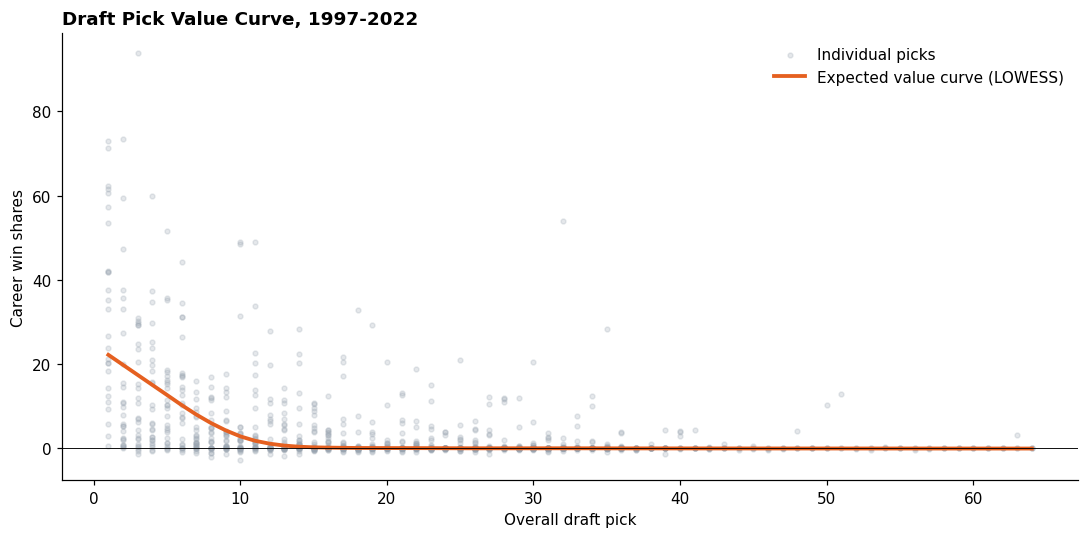

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['overall_pick'], df['win_shares_ev'], s=10, alpha=0.25, color=COLOR_GREY, label='Individual picks')
ax.plot(pick_stats['overall_pick'], pick_stats['expected_win_shares'], color=COLOR_MAIN, linewidth=2.5, label='Expected value curve (LOWESS)')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xlabel('Overall draft pick')
ax.set_ylabel('Career win shares')
ax.set_title('Draft Pick Value Curve, 1997-2022', loc='left', fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('../dashboard/chart_draft_value_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## Bust rate and star rate curves

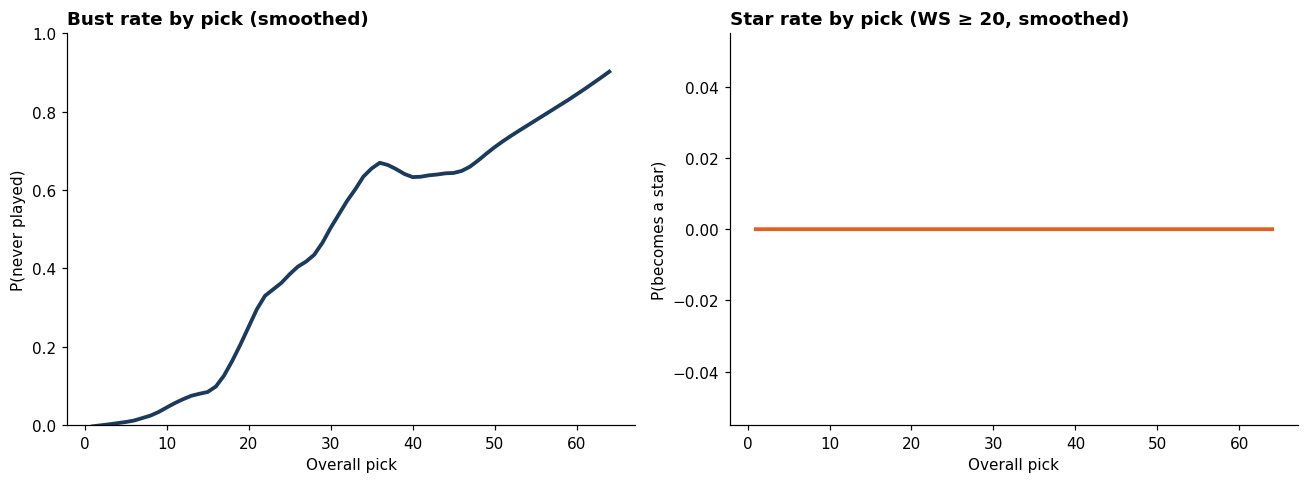

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Smooth these too (same LOWESS approach) so early/late noise doesn't dominate the read
bust_smooth = lowess(df['never_played'].astype(float), df['overall_pick'], frac=0.25, return_sorted=True)
star_smooth = lowess(df['is_star'].astype(float), df['overall_pick'], frac=0.25, return_sorted=True)

axes[0].plot(bust_smooth[:,0], bust_smooth[:,1], color=COLOR_ALT, linewidth=2.5)
axes[0].set_title('Bust rate by pick (smoothed)', loc='left', fontweight='bold')
axes[0].set_xlabel('Overall pick')
axes[0].set_ylabel('P(never played)')
axes[0].set_ylim(0, 1)

axes[1].plot(star_smooth[:,0], star_smooth[:,1], color=COLOR_MAIN, linewidth=2.5)
axes[1].set_title(f'Star rate by pick (WS ≥ {STAR_THRESHOLD:.0f}, smoothed)', loc='left', fontweight='bold')
axes[1].set_xlabel('Overall pick')
axes[1].set_ylabel('P(becomes a star)')

plt.tight_layout()
plt.savefig('../dashboard/chart_bust_star_rate.png', dpi=150, bbox_inches='tight')
plt.show()


## Answering the spec's example question directly

> Is Pick #8 historically more valuable than Pick #5?


In [6]:
def compare_picks(a, b, curve=ev_curve):
    va = curve.loc[curve.overall_pick == a, 'expected_win_shares'].values[0]
    vb = curve.loc[curve.overall_pick == b, 'expected_win_shares'].values[0]
    better = a if va > vb else b
    print(f"Pick #{a}: {va:.2f} expected career win shares")
    print(f"Pick #{b}: {vb:.2f} expected career win shares")
    print(f"-> Pick #{better} carries more historical value "
          f"({'+' if better==a else ''}{abs(va-vb):.2f} WS gap)")

compare_picks(5, 8)


Pick #5: 12.70 expected career win shares
Pick #8: 6.04 expected career win shares
-> Pick #5 carries more historical value (+6.66 WS gap)


## Lottery vs. rest of the draft

In [7]:
lottery_summary = df.groupby('lottery_pick').agg(
    n=('player', 'count'),
    avg_win_shares=('win_shares_ev', 'mean'),
    bust_rate=('never_played', 'mean'),
    star_rate=('is_star', 'mean'),
).round(3)
lottery_summary.index = lottery_summary.index.map({True: 'Lottery (picks 1-4)', False: 'Rest of draft'})
lottery_summary


,n,avg_win_shares,bust_rate,star_rate
lottery_pick,,,,
Rest of draft,958,2.525,0.348,0.029
Lottery (picks 1-4),104,19.650,0.000,0.404


## Save the pick value table

This becomes the baseline that Phase 4's Draft Steal Score is measured against.

In [8]:
pick_value = pick_stats[['overall_pick','n','avg_win_shares','expected_win_shares','bust_rate','star_rate']].copy()
pick_value.to_csv('../data/draft_pick_value.csv', index=False)
print(f"Saved data/draft_pick_value.csv - expected value for all {len(pick_value)} draft slots")
pick_value.round(3)


Saved data/draft_pick_value.csv - expected value for all 64 draft slots


,overall_pick,n,avg_win_shares,expected_win_shares,bust_rate,star_rate
0,1,26,33.027,22.217,0.000,0.692
1,2,26,16.685,19.832,0.000,0.308
2,3,26,15.304,17.452,0.000,0.346
3,4,26,13.585,15.077,0.000,0.269
4,5,26,12.008,12.701,0.038,0.115
...,...,...,...,...,...,...
59,60,3,0.000,-0.010,1.000,0.000
60,61,3,0.000,-0.011,1.000,0.000
61,62,3,0.000,-0.012,1.000,0.000
62,63,3,1.033,-0.013,0.667,0.000
